##### To find best model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler



In [2]:
df = pd.read_csv('test_cleaned.csv')

X = df.drop(['price_range'], axis=1)
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", None)
])

parameter = [

    {
        "classifier": [LogisticRegression(max_iter=5000, solver='saga', random_state=42 )],
        "classifier__penalty": ["l2","l1", None],  # l2 acts as Ridge classification # l1 acts as Lasso classification
        "classifier__C": [0.01, 0.1, 1, 10]
    },

    {
        "classifier": [LogisticRegression(max_iter=1000, solver='saga', random_state=42)],
        "classifier__penalty": ["elasticnet"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__l1_ratio": [0.1, 0.5, 0.9]
    },

    {
        "classifier": [KNeighborsClassifier()],
        "classifier__n_neighbors": [3,5,7,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25],
    },

    {
        "classifier": [DecisionTreeClassifier()],
        "classifier__max_depth": [3,5,7,9,11,13,15,17,19,21,23,25],
        "classifier__criterion": ['gini', 'entropy'],
        "classifier__max_features": [ 'sqrt', 'log2']

    },

    {
        "classifier": [RandomForestClassifier()],
        "classifier__n_estimators": [100,200],
        "classifier__max_depth": [5,10,None]
    },

    {
            
        'classifier': [RidgeClassifier()],
        'classifier__alpha': [0.1, 1.0, 10.0, 100.0]  # alpha controls the penalty strength
    },

    {
        'classifier': [AdaBoostClassifier(random_state=42, algorithm='SAMME')],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 1.0]
    },

{
        'classifier': [GradientBoostingClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, None],
        'classifier__learning_rate': [0.01, 0.1]
    },

    {
        'classifier': [XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')],
        'classifier__n_estimators': [100, 200],     # Number of gradient boosted trees
        'classifier__max_depth': [3, 5, 6],         # Maximum depth of a tree
        'classifier__learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage
    }



]

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameter,
    cv=5,  # 5-fold cross-validation
    scoring="accuracy",
    n_jobs=-1,  # Use all available CPU cores
)

print("Training all models in parallel...")
grid_search.fit(X_train, y_train)


print("\n--- Best Model Found ---")
print(grid_search.best_params_["classifier"])
print(f"Best CV Training Accuracy: {grid_search.best_score_:.4f}")

# Evaluate the best pipeline on unseen test data
test_accuracy = grid_search.score(X_test, y_test)
print(f"Final Test Accuracy: {test_accuracy:.4f}")


Training all models in parallel...

--- Best Model Found ---
LogisticRegression(max_iter=5000, random_state=42, solver='saga')
Best CV Training Accuracy: 0.9688
Final Test Accuracy: 0.9800


##### testing data

In [22]:
test_data = pd.read_csv('test.csv')

test_data.head()









,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


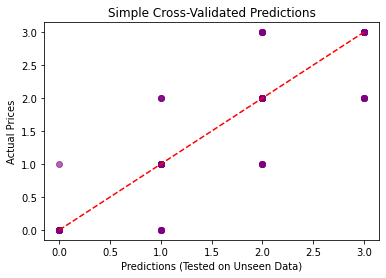

Final Test Accuracy: 0.9860


In [26]:
Xt = test_data.drop(['price_range'], axis=1)

yt = test_data['price_range'].values


pred_yt = grid_search.predict(Xt)

# 5. PLOT THE RESULTS
plt.scatter(pred_yt, yt, color="purple", alpha=0.6)

# A red line showing where "perfect predictions" would land
plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], color="red", linestyle="--")

plt.xlabel("Predictions (Tested on Unseen Data)")
plt.ylabel("Actual Prices")
plt.title("Simple Cross-Validated Predictions")
plt.show()

test_accuracy = grid_search.score(Xt, yt)
print(f"Final Test Accuracy: {test_accuracy:.4f}")




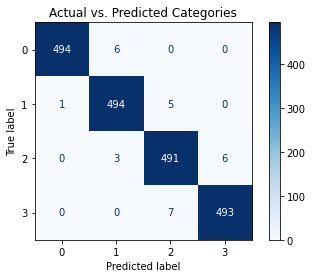

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Compute the confusion matrix
cm = confusion_matrix(yt, pred_yt)

# 3. Plot the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Actual vs. Predicted Categories")
plt.show()